In [1]:
# Re-run simulation quickly with corrected indexing
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

Gene category counts:
 None    880
DE o     40
Both     40
Modu     40
Name: count, dtype: int64


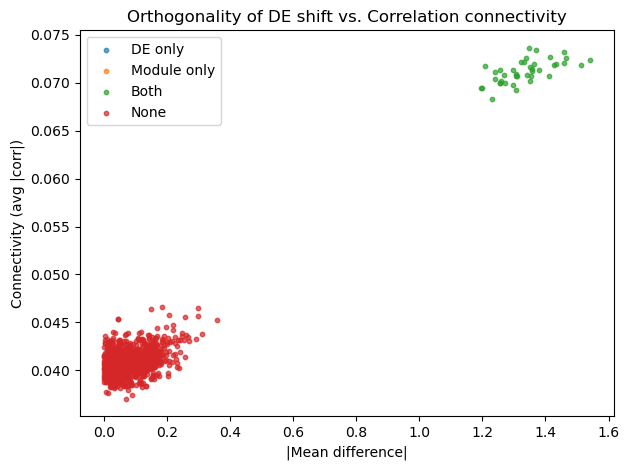

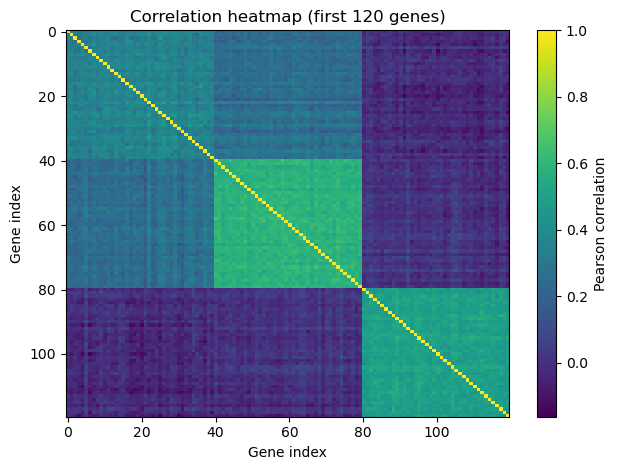

In [2]:
np.random.seed(42)
n_cells = 400
p_genes = 1000
group_labels = np.repeat([0, 1], n_cells // 2)

idx_de_only = np.arange(0, 40)
idx_both = np.arange(40, 80)
idx_module_only = np.arange(80, 120)
idx_none = np.arange(120, p_genes)

mu = np.random.normal(size=p_genes)
X = np.zeros((n_cells, p_genes))

for i in range(n_cells):
    X[i, :] = mu + np.random.normal(size=p_genes)

delta = np.zeros(p_genes)
delta[idx_de_only] = 1.5
delta[idx_both] = 1.5

X[group_labels == 1, :] += delta

alpha = 1.0
latent_module1 = np.random.normal(size=n_cells)
latent_module2 = np.random.normal(size=n_cells)
for i in range(n_cells):
    X[i, idx_both] += alpha * latent_module1[i]
    X[i, idx_module_only] += alpha * latent_module2[i]

expr_df = pd.DataFrame(X, columns=[f"Gene{j}" for j in range(p_genes)])
labels_series = pd.Series(group_labels, name="Group")

de_results = []
for j in range(p_genes):
    group0 = expr_df[labels_series == 0].iloc[:, j]
    group1 = expr_df[labels_series == 1].iloc[:, j]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
    mean_diff = group1.mean() - group0.mean()
    de_results.append((j, mean_diff, t_stat, p_val))

de_df = pd.DataFrame(de_results, columns=["GeneIndex", "MeanDiff", "Tstat", "Pval"])

corr_mat = np.corrcoef(X, rowvar=False)
connectivity = np.mean(np.abs(corr_mat), axis=0)
de_df["Connectivity"] = connectivity

category = np.repeat("None", p_genes)
category[idx_de_only] = "DE only"
category[idx_both] = "Both"
category[idx_module_only] = "Module only"
de_df["Category"] = category

counts = pd.Series(category).value_counts()
print("Gene category counts:\n", counts)

plt.figure()
for cat in ["DE only", "Module only", "Both", "None"]:
    mask = de_df["Category"] == cat
    plt.scatter(
        np.abs(de_df.loc[mask, "MeanDiff"]),
        de_df.loc[mask, "Connectivity"],
        label=cat,
        alpha=0.7,
        s=10
    )
plt.xlabel("|Mean difference|")
plt.ylabel("Connectivity (avg |corr|)")
plt.title("Orthogonality of DE shift vs. Correlation connectivity")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.imshow(corr_mat[:120, :120], aspect='auto')
plt.colorbar(label="Pearson correlation")
plt.title("Correlation heatmap (first 120 genes)")
plt.xlabel("Gene index")
plt.ylabel("Gene index")
plt.tight_layout()
plt.show()

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


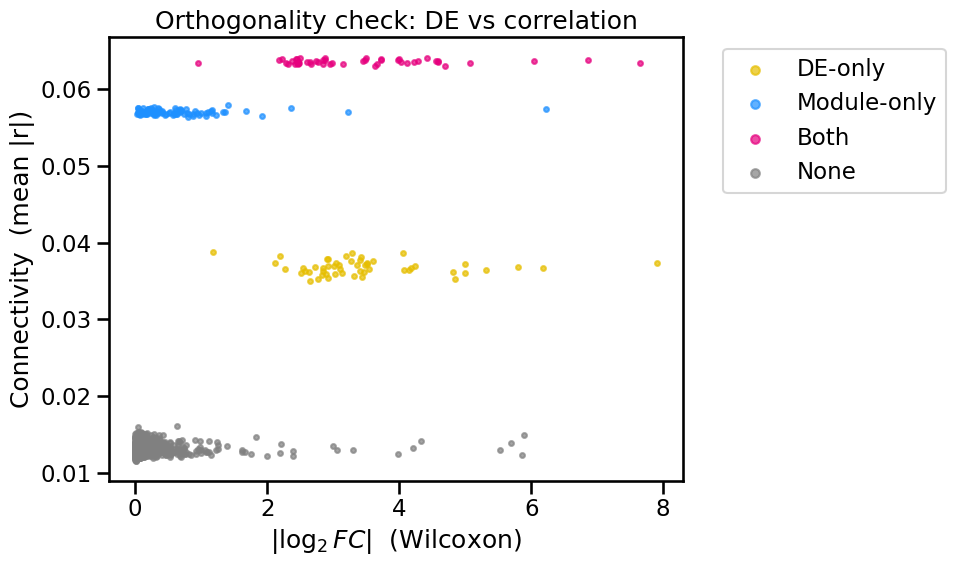


Cut-offs:
  • |logFC| > 0.50 counts as DE
  • Connectivity > 0.049 counts as highly connected

High connectivity?  False  True 
DE?                             
False                1662    109
True                  138     91


In [17]:
# ----------------------------------------------------------
# 0. SET-UP  •  one-time installs (comment out after first run)
# ----------------------------------------------------------
# !pip install scanpy anndata matplotlib pandas scipy seaborn

# ----------------------------------------------------------
# 1. IMPORTS
# ----------------------------------------------------------
import numpy as np, pandas as pd, scanpy as sc
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# prettier plots
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (5,4)

# ----------------------------------------------------------
# 2. SIMULATION PARAMETERS  (feel free to tweak)
# ----------------------------------------------------------
n_cells        = 4000                 # 200 control + 200 treated
p_genes        = 2000
de_shift       = 1.5                 # mean shift for DE genes
latent_weight  = 3.0                 # strength of module correlation
module_size    = 100                  # genes per module

idx_de_only      = np.arange(0, module_size)
idx_both         = np.arange(module_size, module_size*2)
idx_module_only  = np.arange(module_size*2, module_size*3)
idx_none         = np.arange(module_size*3, p_genes)

# ----------------------------------------------------------
# 3. SIMULATE EXPRESSION MATRIX  X  (cells × genes)
# ----------------------------------------------------------
rng = np.random.default_rng(42)
mu = rng.normal(0, 1, p_genes)                 # gene-specific baseline mean
X  = rng.normal(mu, 1, size=(n_cells, p_genes))# baseline noise              

# group labels: 0 = control, 1 = treated
group_labels = np.repeat([0, 1], n_cells//2)

# add differential-expression shift (+ de_shift in treated)
delta              = np.zeros(p_genes)
delta[idx_de_only] = delta[idx_both] = de_shift
X[group_labels==1] += delta

# add *two* latent factors to create correlation modules
latent_mod1 = rng.normal(size=n_cells)
latent_mod2 = rng.normal(size=n_cells)
X[:, idx_both]        += latent_weight * latent_mod1[:, None]
X[:, idx_module_only] += latent_weight * latent_mod2[:, None]

# ----------------------------------------------------------
# 4. WRAP INTO AnnData (Scanpy format)
# ----------------------------------------------------------
adata = sc.AnnData(X)
adata.obs["group"] = pd.Categorical(group_labels)      # metadata
adata.var["true_category"] = ["DE-only"      ]*module_size   \
                           + ["Both"         ]*module_size   \
                           + ["Module-only"  ]*module_size   \
                           + ["None"         ]*(p_genes-3*module_size)

# ----------------------------------------------------------
# 5. DIFFERENTIAL EXPRESSION  (Wilcoxon)
# ----------------------------------------------------------
sc.tl.rank_genes_groups(
    adata,
    groupby      = "group",
    groups       = "all",            # treated vs all controls
    reference    = "rest",
    method       = "wilcoxon",
    use_raw      = False,
    tie_correct  = True
)

# Extract gene-wise |logFC| (Scanpy stores it in .uns)
de_df = sc.get.rank_genes_groups_df(adata, group="1")
adata.var["logFC"] = 0.0
adata.var.loc[de_df["names"], "logFC"] = np.abs(de_df["logfoldchanges"].values)

# ----------------------------------------------------------
# 6. CORRELATION MATRIX  →  “connectivity” score
# ----------------------------------------------------------
# Pearson corr across ALL cells (safe for demonstration; real data = use centred groups)
corr = np.corrcoef(adata.X, rowvar=False)
connectivity = np.abs(corr).mean(axis=0)      # mean |r| to every other gene
adata.var["connectivity"] = connectivity

# ----------------------------------------------------------
# 7. DIAGNOSTIC SCATTER PLOT  (DE vs correlation)
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10,6))
for cat, color in zip(["DE-only", "Module-only", "Both", "None"],
                      ["#e6be00", "#1e90ff", "#e6007e", "gray"]):
    mask = adata.var["true_category"] == cat
    ax.scatter(adata.var.loc[mask, "logFC"],
               adata.var.loc[mask, "connectivity"],
               s=12, alpha=0.7, label=cat, color=color)

ax.set_xlabel(r"$| \log_{2}FC |$  (Wilcoxon)")
ax.set_ylabel("Connectivity  (mean |r|)")
ax.set_title("Orthogonality check: DE vs correlation")
ax.legend(markerscale=1.8, bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 8. QUICK “PASS / FAIL” SUMMARY
# ----------------------------------------------------------
th_fc   = 0.5            # arbitrary threshold for DE
th_conn = connectivity.mean() + 2*connectivity.std()   # high-conn cut-off

print("\nCut-offs:")
print(f"  • |logFC| > {th_fc:.2f} counts as DE")
print(f"  • Connectivity > {th_conn:.3f} counts as highly connected\n")

tbl = pd.crosstab(
    index  = (adata.var["logFC"] > th_fc),
    columns= (adata.var["connectivity"] > th_conn),
    rownames=["DE?"],
    colnames=["High connectivity?"]
)
print(tbl)


DE‑only gold
Module‑only dodgerblue
None gray


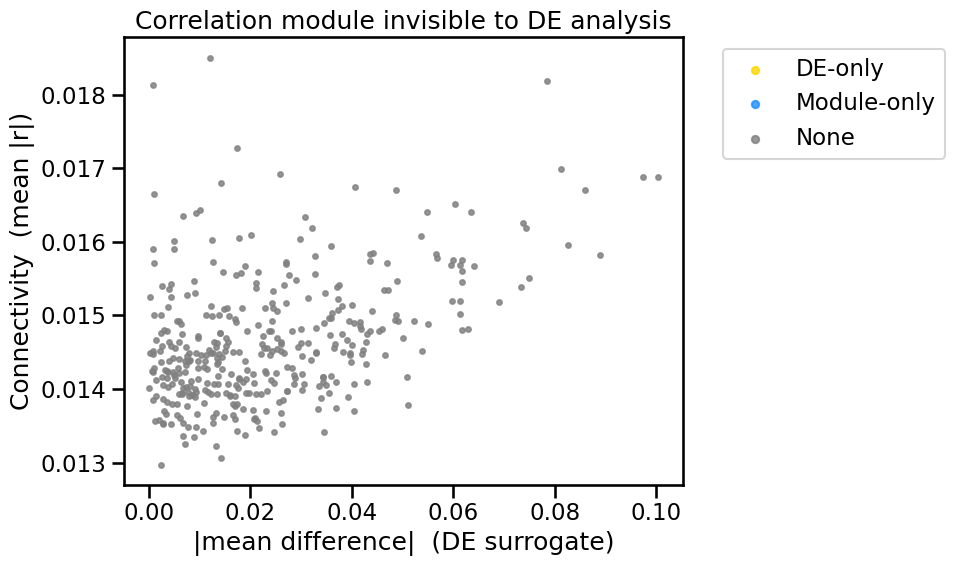

Conn > μ+2σ?,False,True
DE > 0.5?,,
False,380,60
True,60,0


In [29]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# --- simulate without Scanpy to avoid dependency ---
rng = np.random.default_rng(123)
n_cells = 4000
p_genes = 500

groups = np.repeat([0, 1], n_cells // 2)

g_module_only = np.arange(0, 60)
g_de_only = np.arange(60, 120)
g_background = np.arange(120, p_genes)

mu = rng.normal(0, 1, p_genes)
X = rng.normal(mu, 1, size=(n_cells, p_genes))

delta = np.zeros(p_genes)
delta[g_de_only] = 1.5
X[groups == 1] += delta

latent = rng.normal(0, 1, n_cells)
X[:, g_module_only] += latent[:, None]

# compute |mean diff| as logFC surrogate
mean_diff = np.abs(X[groups == 1].mean(axis=0) - X[groups == 0].mean(axis=0))

# connectivity (mean |corr| across all cells)
corr = np.corrcoef(X, rowvar=False)
connectivity = np.abs(corr).mean(axis=0)

categories = np.array(["None"]*p_genes)
categories[g_module_only] = "Module‑only"
categories[g_de_only] = "DE‑only"

# scatter
sns.set_context("talk")
palette = {"DE‑only":"gold", "Module‑only":"dodgerblue", "None":"gray"}
plt.figure(figsize=(10,6))
for cat, color in palette.items():
    print(cat,color)
    m = categories == cat
    plt.scatter(mean_diff[m], connectivity[m], color=color, label=cat, s=12, alpha=0.8)
plt.xlabel("|mean difference|  (DE surrogate)")
plt.ylabel("Connectivity  (mean |r|)")
plt.title("Correlation module invisible to DE analysis")
plt.legend(markerscale=1.5, bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# contingency
de_cut = 0.5
hub_cut = connectivity.mean() + 2*connectivity.std()
table = pd.crosstab(mean_diff > de_cut, connectivity > hub_cut,
                    rownames=["DE > 0.5?"], colnames=["Conn > μ+2σ?"])
table


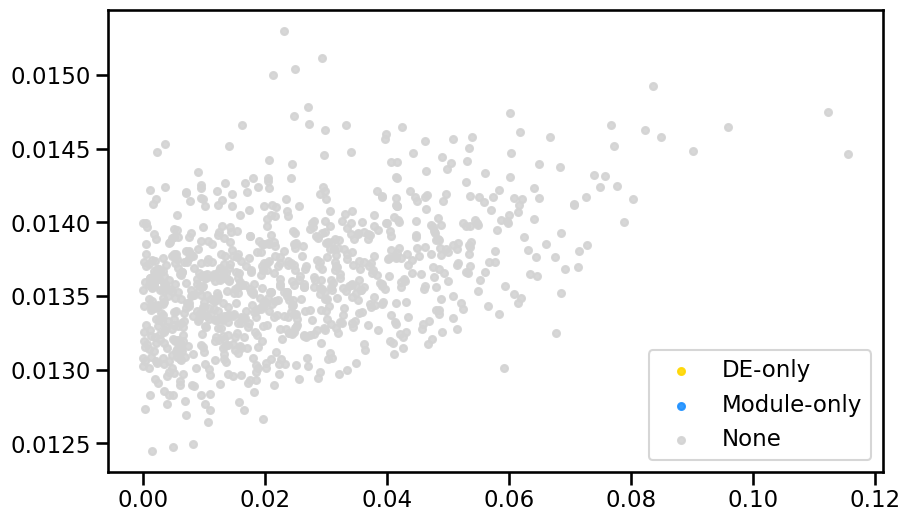

In [22]:
plt.figure(figsize=(10,6))
for cat, col in [("DE-only","gold"), ("Module-only","dodgerblue"), ("None","lightgrey")]:
    m = categories == cat
    plt.scatter(mean_diff[m], connectivity[m], s=25, alpha=.9, color=col, label=cat)
plt.legend()
plt.show()


In [1]:
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


corr(cluster, q) = 0.705
corr(cluster, z) = 0.007

----------  summary  ----------
module genes               : 50
DEA hits (|logFC|>0.5)     : 2819
… which are module genes   : 0
------------------------------



/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Figure saved ➜ /home/momo/Repos/ABCA_analysis/Dissertation/dea_vs_cna_fair_demo.png


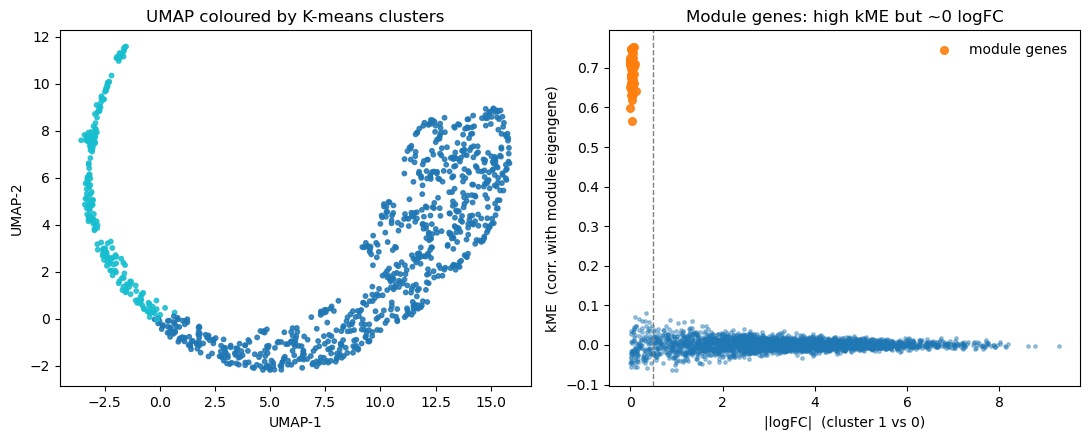

In [2]:
# ------------------------------------------------------------
# 0 . utility: 2-D embedder (UMAP preferred, t-SNE fallback)
try:
    import umap  # type: ignore

    def reduce2d(x):  # pylint: disable=invalid-name
        return umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=42).fit_transform(x)

    red_name = "UMAP"
except ImportError:
    from sklearn.manifold import TSNE  # type: ignore

    def reduce2d(x):  # pylint: disable=invalid-name
        return TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(x)

    red_name = "t-SNE"


# ------------------------------------------------------------
# 1 . simulate counts
def simulate(
    n_cells: int = 1000,
    n_genes: int = 3000,
    module_size: int = 50,
    latent_var: float = 1.0,
    cluster_var: float = 3.0,
    noise_var: float = 1.0,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    * z  – latent factor driving the hidden module   (continuous, no clusters)
    * q  – background factor that *does* define clusters
    """
    rng = np.random.default_rng(seed)
    module_idx = rng.choice(n_genes, module_size, replace=False)
    bg_idx = np.setdiff1d(np.arange(n_genes), module_idx)

    z = rng.normal(0, latent_var, size=n_cells)      # hidden programme
    q = rng.normal(0, cluster_var, size=n_cells)     # drives clustering

    X = np.zeros((n_cells, n_genes), dtype=np.float32)  # counts (log-scale later)

    # module genes – depend only on z
    for g in module_idx:
        w = rng.uniform(0.8, 1.2)
        X[:, g] = np.exp(w * z + rng.normal(0, noise_var, size=n_cells))

    # background genes – depend only on q
    for g in bg_idx:
        a = rng.normal(1.0, 0.5)
        X[:, g] = np.exp(a * q + rng.normal(0, noise_var, size=n_cells))

    logX = np.log1p(X)
    return logX, module_idx, z, q


# ------------------------------------------------------------
# 2 . run the analysis
def main() -> None:
    LOGX, MOD, z, q = simulate()  # LOGX shape = (cells, genes)
    G = LOGX.shape[1]

    # ---------------- clustering on *all* genes ----------------
    pcs = PCA(n_components=20, random_state=42).fit_transform(StandardScaler().fit_transform(LOGX))
    clusters = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(pcs)

    # quick sanity: clusters should align with q, not with z
    print(f"corr(cluster, q) = {np.corrcoef(clusters, q)[0,1]:.3f}")
    print(f"corr(cluster, z) = {np.corrcoef(clusters, z)[0,1]:.3f}\n")

    # ---------------- differential expression -----------------
    cl_mean = np.vstack([LOGX[clusters == k].mean(axis=0) for k in [0, 1]])
    abs_logFC = np.abs(cl_mean[1] - cl_mean[0])
    n_de_total = (abs_logFC > 0.5).sum()
    n_de_module = (abs_logFC[MOD] > 0.5).sum()

    # ---------------- connectivity (kME) ----------------------
    eig = LOGX[:, MOD].mean(axis=1)
    eig -= eig.mean()
    kME = np.array(
        [
            np.corrcoef(LOGX[:, g] - LOGX[:, g].mean(), eig)[0, 1]
            for g in range(G)
        ],
        dtype=float,
    )

    print("----------  summary  ----------")
    print(f"module genes               : {len(MOD)}")
    print(f"DEA hits (|logFC|>0.5)     : {n_de_total}")
    print(f"… which are module genes   : {n_de_module}")
    print("------------------------------\n")

    # ---------------- 2-D embedding ----------------------------
    emb = reduce2d(pcs)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    sc1 = axes[0].scatter(
        emb[:, 0], emb[:, 1], c=clusters, cmap="tab10", s=10, alpha=0.85, rasterized=True
    )
    axes[0].set_title(f"{red_name} coloured by K-means clusters")
    axes[0].set_xlabel(f"{red_name}-1")
    axes[0].set_ylabel(f"{red_name}-2")

    # scatter of DEA vs CNA
    bg = np.setdiff1d(np.arange(G), MOD)
    axes[1].scatter(abs_logFC[bg], kME[bg], s=6, alpha=0.4, rasterized=True)
    axes[1].scatter(abs_logFC[MOD], kME[MOD], s=30, alpha=0.9, label="module genes")
    axes[1].axvline(0.5, ls="--", lw=1, color="grey")
    axes[1].set_xlabel("|logFC|  (cluster 1 vs 0)")
    axes[1].set_ylabel("kME  (corr. with module eigengene)")
    axes[1].set_title("Module genes: high kME but ~0 logFC")
    axes[1].legend(frameon=False)

    fig.tight_layout()
    out = Path("dea_vs_cna_fair_demo.png")
    fig.savefig(out, dpi=300)
    print(f"Figure saved ➜ {out.resolve()}")


if __name__ == "__main__":
    main()
